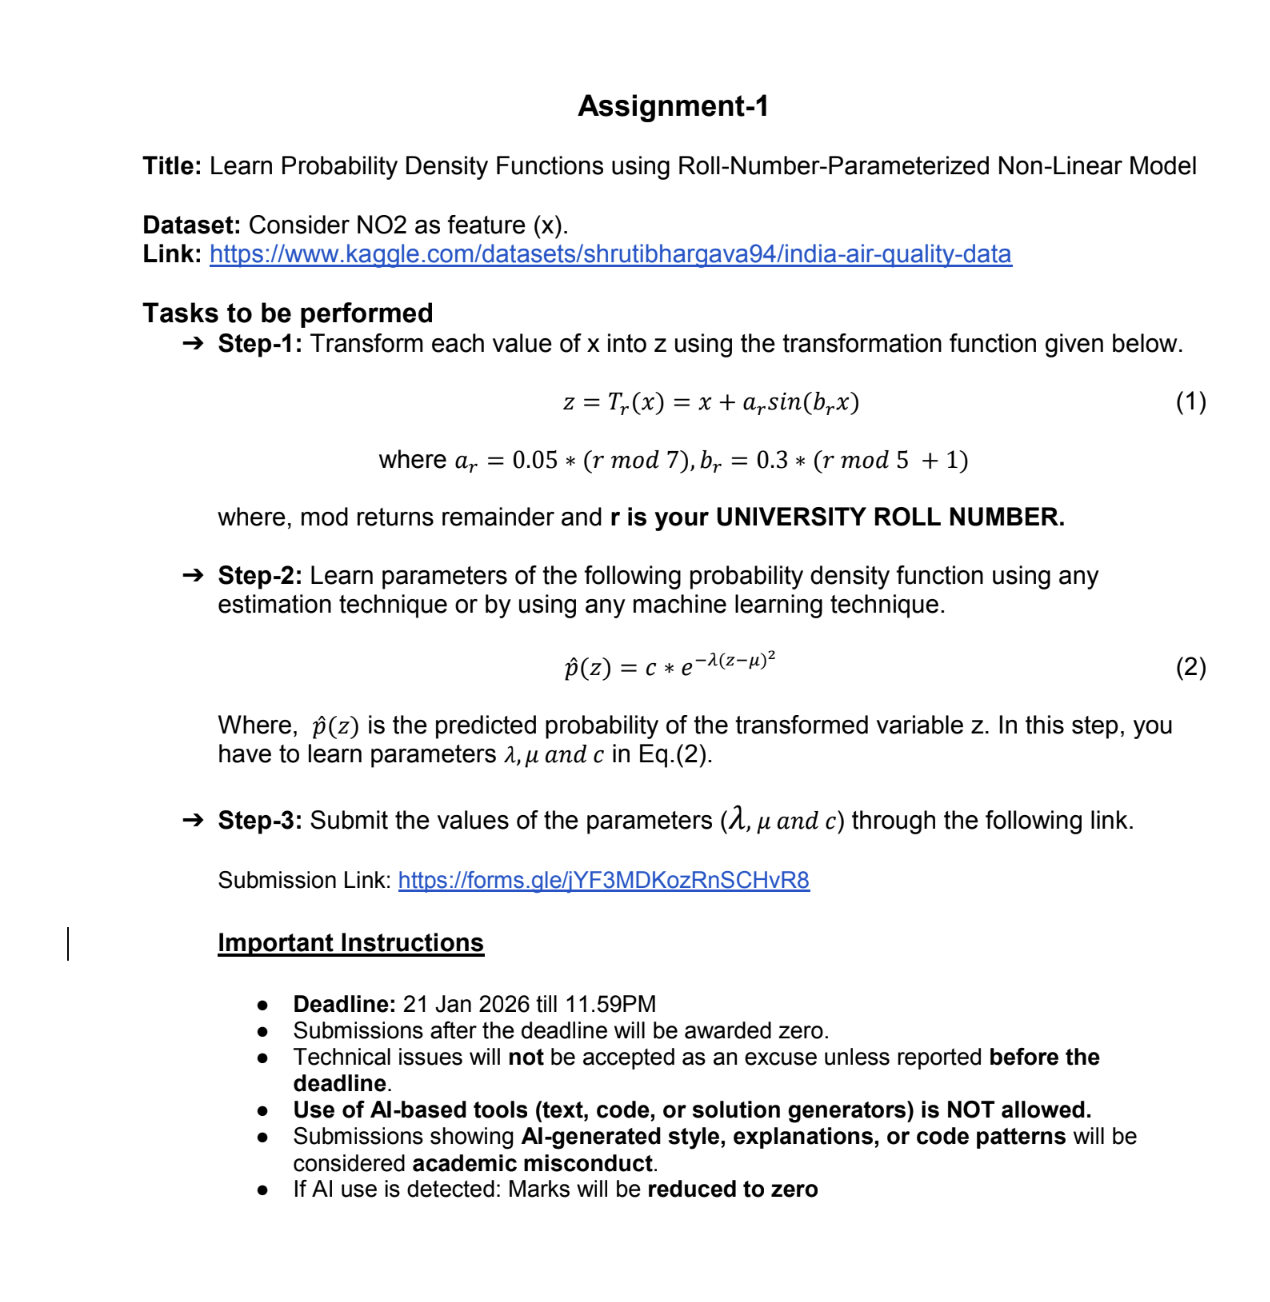

Loading and Analysing Dataset

In [3]:
import pandas as pd
df = pd.read_csv("/content/data.csv", encoding="latin1")
df.head()

/tmp/ipython-input-3471336113.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data.csv", encoding="latin1")


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [5]:
print('Shape:', df.shape)
print('\nColumns:\n', df.columns)

print('\nInfo:')
df.info()

print('\nData Types:\n', df.dtypes)

print('\nMissing Values:\n', df.isnull().sum())

print('\nDuplicate Rows:', df.duplicated().sum())

print('\nSummary Statistics:\n', df.describe())

print('\nUnique Values Count:\n', df.nunique())

Shape: (435742, 13)

Columns:
 Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm     

Step 1

In [6]:
import numpy as np

r = 102317003

a_r = 0.05 * (r % 7)
b_r = 0.3 * (r % 5 + 1)

df["z"] = df["no2"] + a_r * np.sin(b_r * df["no2"])

print(df[["no2", "z"]].head())


    no2          z
0  17.4  17.624052
1   7.0   7.213650
2  28.5  28.587488
3  14.7  14.466135
4   7.5   7.603030


Step 2

In [7]:
z_values = df["z"].dropna()

mu = z_values.mean()

variance = z_values.var()

lambda_val = 1 / (2 * variance)

c = np.sqrt(lambda_val / np.pi)

df["p_hat_z"] = c * np.exp(-lambda_val * (df["z"] - mu) ** 2)

print("mu =", mu)
print("lambda =", lambda_val)
print("c =", c)

print(df[["z", "p_hat_z"]].head())


mu = 25.804148934144695
lambda = 0.001459636022685789
c = 0.021554966394102183
           z   p_hat_z
0  17.624052  0.019549
1   7.213650  0.013016
2  28.587488  0.021313
3  14.466135  0.017867
4   7.603030  0.013291


Link for submission in Step 3 is not working.